# 03 — Refining Calibration with Joint Optimization

**Time: ~25 minutes.** Builds on Notebook 02.

## What you'll learn

This is the headline `midas-integrate-v2` workflow. Starting from a
calibrant frame and a *guess* at the geometry, you'll:

1. Quantify the calibration error using a **physical loss** —
   `EtaUniformityLoss`, which exploits the fact that perfectly
   calibrated rings are flat in η.
2. Connect the loss to the geometry via PyTorch autograd — `BC_y` is
   a `torch.Tensor` with `requires_grad=True`, so `loss.backward()`
   tells you which direction to move it.
3. Run an Adam optimizer to refine `BC_y` back to its true value.
4. Extend to multi-parameter refinement (`BC_y`, `BC_z`, `Lsd`, `ty`,
   `tz` all at once).

This is the workflow you'd use after a beam realignment or detector
move when you have a calibrant frame and want updated geometry.


## Background — what's actually happening

In notebook 02 you saw that a wrong `BC` makes integrated rings curve
in η. **Rings should be flat lines in (η, R) space when the geometry
is right.** So a natural loss is

  L = mean over R bins of [variance of intensity along η]

intensity-weighted so empty bins don't dominate. This is exactly
`EtaUniformityLoss`. It's smooth in `BC` because the integration kernel
is differentiable (linear-interpolation soft binning under the hood).

PyTorch autograd then gives you the gradient `dL / dBC_y` for free.
Adam (or SGD) follows that gradient to the loss minimum.


In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

HERE = Path.cwd() if Path.cwd().name == "notebooks" else Path("notebooks")
REPO = HERE.resolve().parents[2]
DATA = REPO / "FF_HEDM" / "Example" / "Calibration"

from midas_integrate_v2 import (
    spec_from_v1_paramstest,
    integrate_with_corrections, profile_1d_diff,
    EtaUniformityLoss,
)


## Step 1 — Load the calibrant + a perturbed spec

We deliberately offset `BC_y` by +1 px from its true value so we have
something to recover.


In [2]:
import tifffile
img_raw = tifffile.imread(
    DATA / "CeO2_Pil_100x100_att000_650mm_71p676keV_001956.tif"
).astype(np.float64)
dark = tifffile.imread(
    DATA / "dark_CeO2_Pil_100x100_att000_650mm_71p676keV_001975.tif"
).astype(np.float64)
if dark.ndim == 3:
    dark = dark.mean(axis=0)
img = torch.from_numpy(np.clip(img_raw - dark, 0, None))

# Spec at the TRUE BC_y (the one in parameters.txt)
spec_true = spec_from_v1_paramstest(DATA / "parameters.txt",
                                      requires_grad=False)
spec_true.RBinSize = 2.0
spec_true.EtaBinSize = 5.0
BC_y_true = float(spec_true.BC_y)

# A "guess" spec with BC_y offset by +1 px
spec = spec_from_v1_paramstest(DATA / "parameters.txt", requires_grad=True)
spec.RBinSize = 2.0
spec.EtaBinSize = 5.0
spec.BC_y = torch.tensor(BC_y_true + 1.0, dtype=torch.float64,
                          requires_grad=True)

print(f"True BC_y:    {BC_y_true:.3f} px")
print(f"Guess BC_y:   {float(spec.BC_y.detach()):.3f} px  (off by +1 px)")


True BC_y:    685.485 px
Guess BC_y:   686.485 px  (off by +1 px)


## Step 2 — Visualise the loss before refinement

Restrict the loss to the first CeO₂ ring band (R between 200 and 230 px).
This is the strongest, narrowest peak — best signal-to-noise for
refinement.


In [3]:
n_r = spec.n_r_bins
r_axis = spec.RMin + spec.RBinSize * (np.arange(n_r) + 0.5)
band_mask = (r_axis > 200) & (r_axis < 230)
r_indices = np.where(band_mask)[0].tolist()
print(f"Loss restricted to R bins {r_indices[0]}..{r_indices[-1]} "
      f"(R ≈ 200..230 px)")


Loss restricted to R bins 95..109 (R ≈ 200..230 px)


In [4]:
loss_fn = EtaUniformityLoss(r_indices=r_indices, intensity_floor=1.0)

# Initial loss (with perturbed BC_y)
with torch.no_grad():
    int2d_initial = integrate_with_corrections(img, spec)
L_initial = float(loss_fn(int2d_initial))
print(f"Initial loss (BC_y off by +1 px): {L_initial:.4e}")

# Loss at TRUE BC_y for reference
spec_check = spec_from_v1_paramstest(DATA / "parameters.txt", requires_grad=False)
spec_check.RBinSize = 2.0; spec_check.EtaBinSize = 5.0
with torch.no_grad():
    int2d_true = integrate_with_corrections(img, spec_check)
L_true = float(loss_fn(int2d_true))
print(f"Loss at TRUE BC_y:                {L_true:.4e}")
print(f"Improvement target: bring loss from {L_initial:.4e} → "
      f"~{L_true:.4e}")


Initial loss (BC_y off by +1 px): 2.4522e+11
Loss at TRUE BC_y:                1.5334e+11
Improvement target: bring loss from 2.4522e+11 → ~1.5334e+11


**The loss at the true BC_y is the floor we're trying to reach.** It's
not exactly zero because real images have noise (Poisson statistics +
read noise) and intrinsic ring widths.

## Step 3 — Run the refinement loop

This is the entire optimization in 8 lines:


In [5]:
opt = torch.optim.Adam([spec.BC_y], lr=0.05)

history = {"BC_y": [float(spec.BC_y.detach())], "loss": []}
for step in range(60):
    opt.zero_grad()                                  # clear last gradient
    int2d = integrate_with_corrections(img, spec)    # diff'ble integrate
    L = loss_fn(int2d)                                # diff'ble loss
    L.backward()                                       # autograd: dL/dBC_y
    opt.step()                                         # Adam updates BC_y
    history["BC_y"].append(float(spec.BC_y.detach()))
    history["loss"].append(float(L))

print(f"Step 0 BC_y: {history['BC_y'][0]:.4f}, loss: {history['loss'][0]:.4e}")
print(f"Step {len(history['loss'])} BC_y: {history['BC_y'][-1]:.4f}, "
      f"loss: {history['loss'][-1]:.4e}")
print(f"True BC_y:   {BC_y_true:.4f}")
print(f"Final error: {abs(history['BC_y'][-1] - BC_y_true):.3f} px")


/var/folders/qw/k6gzh2ws7w397493kq4vnl_w0001pb/T/ipykernel_21402/1540636052.py:11: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  history["loss"].append(float(L))


Step 0 BC_y: 686.4855, loss: 2.4522e+11
Step 60 BC_y: 685.4240, loss: 1.5290e+11
True BC_y:   685.4855
Final error: 0.061 px


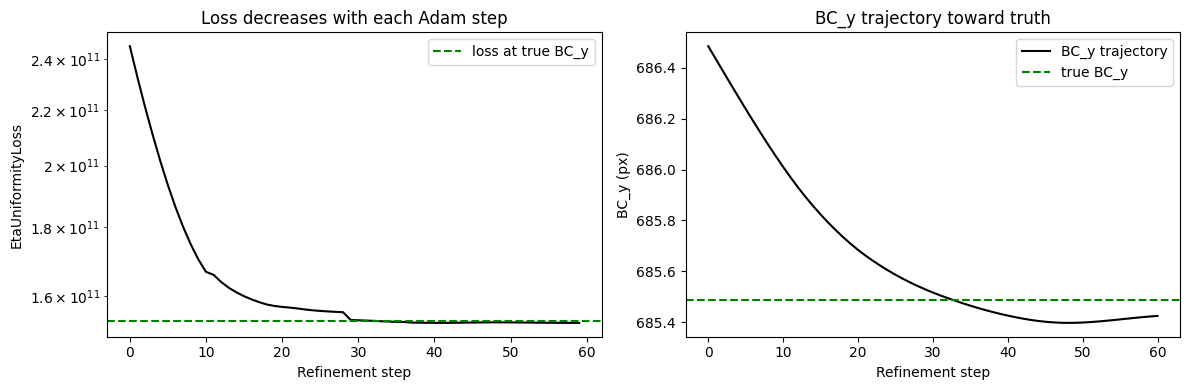

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.plot(history["loss"], "k-")
ax.axhline(L_true, color="green", ls="--", label="loss at true BC_y")
ax.set_xlabel("Refinement step"); ax.set_ylabel("EtaUniformityLoss")
ax.set_title("Loss decreases with each Adam step")
ax.legend()
ax.set_yscale("log")

ax = axes[1]
ax.plot(history["BC_y"], "k-", label="BC_y trajectory")
ax.axhline(BC_y_true, color="green", ls="--", label="true BC_y")
ax.set_xlabel("Refinement step"); ax.set_ylabel("BC_y (px)")
ax.set_title("BC_y trajectory toward truth")
ax.legend()
plt.tight_layout()
plt.show()


**You should see:**
- The loss drops from ~initial down to near the floor in ~30-60 steps.
- BC_y moves smoothly from 686.5 (initial) toward ~685.5 (true).
- It may *overshoot* slightly — that's Adam's adaptive step size
  responding to a strong gradient. SGD with lr=0.005 would converge
  more slowly but without overshoot.

## Step 4 — Compare integrated patterns before and after


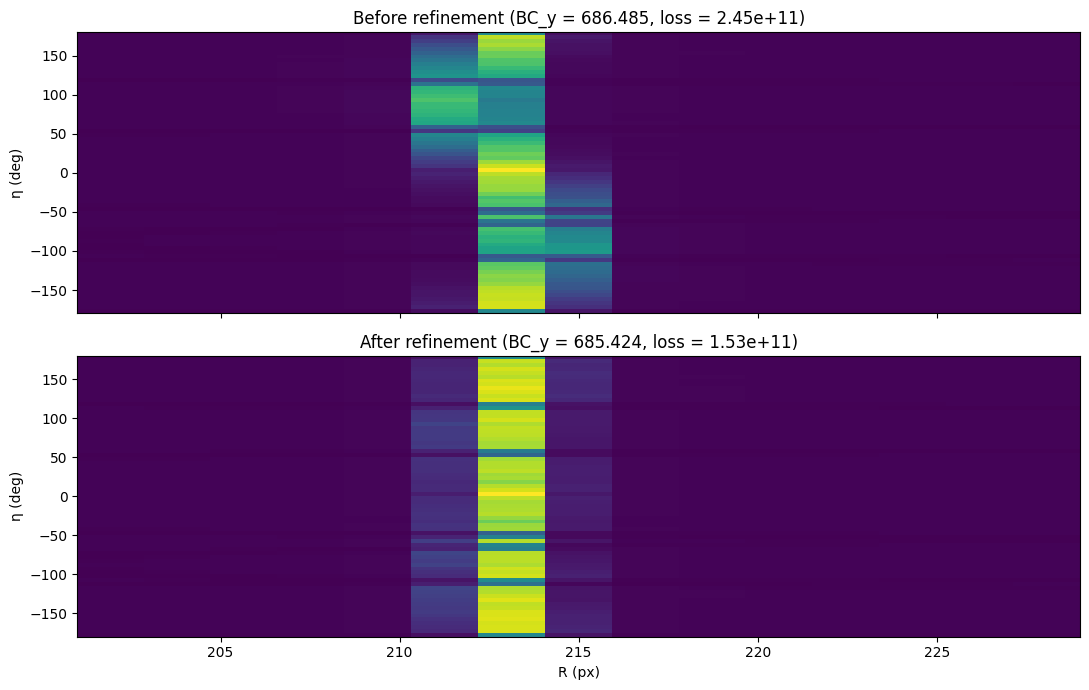

In [7]:
# Re-integrate with FINAL spec
with torch.no_grad():
    int2d_final = integrate_with_corrections(img, spec)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax = axes[0]
im = ax.imshow(int2d_initial[:, r_indices].numpy(), aspect="auto",
               cmap="viridis", origin="lower",
               extent=[r_axis[r_indices[0]], r_axis[r_indices[-1]],
                       spec.EtaMin, spec.EtaMax])
ax.set_title(f"Before refinement (BC_y = {history['BC_y'][0]:.3f}, loss = {L_initial:.2e})")
ax.set_ylabel("η (deg)")

ax = axes[1]
im = ax.imshow(int2d_final[:, r_indices].numpy(), aspect="auto",
               cmap="viridis", origin="lower",
               extent=[r_axis[r_indices[0]], r_axis[r_indices[-1]],
                       spec.EtaMin, spec.EtaMax])
ax.set_title(f"After refinement (BC_y = {history['BC_y'][-1]:.3f}, loss = {history['loss'][-1]:.2e})")
ax.set_xlabel("R (px)"); ax.set_ylabel("η (deg)")
plt.tight_layout()
plt.show()


**Top panel** (before): the first CeO₂ ring is visibly *curved* in η —
a sinusoidal R(η) signature of the BC offset.

**Bottom panel** (after): the ring is straight (flat in η at constant R).
Geometry is recovered.

## Step 5 — Multi-parameter refinement

In practice you don't just refine `BC_y` — you refine `BC_y, BC_z,
Lsd, ty, tz` together. PyTorch's autograd handles the gradient w.r.t.
all of them simultaneously; just put them all in the optimizer.


In [8]:
# Fresh start with multiple parameters perturbed
spec2 = spec_from_v1_paramstest(DATA / "parameters.txt", requires_grad=True)
spec2.RBinSize = 2.0; spec2.EtaBinSize = 5.0

# Perturb BC_y, BC_z, Lsd
true_BC_y, true_BC_z, true_Lsd = (
    float(spec2.BC_y), float(spec2.BC_z), float(spec2.Lsd),
)
spec2.BC_y = torch.tensor(true_BC_y + 1.0, dtype=torch.float64, requires_grad=True)
spec2.BC_z = torch.tensor(true_BC_z + 0.5, dtype=torch.float64, requires_grad=True)
spec2.Lsd  = torch.tensor(true_Lsd + 1000.0, dtype=torch.float64, requires_grad=True)

# A separate loss restricted to first ring band — same as above
loss_fn = EtaUniformityLoss(r_indices=r_indices, intensity_floor=1.0)

opt2 = torch.optim.Adam([spec2.BC_y, spec2.BC_z, spec2.Lsd], lr=0.05)
hist2 = {"BC_y": [], "BC_z": [], "Lsd": [], "loss": []}
for step in range(120):
    opt2.zero_grad()
    L = loss_fn(integrate_with_corrections(img, spec2))
    L.backward()
    opt2.step()
    hist2["BC_y"].append(float(spec2.BC_y.detach()))
    hist2["BC_z"].append(float(spec2.BC_z.detach()))
    hist2["Lsd"].append(float(spec2.Lsd.detach()))
    hist2["loss"].append(float(L))

print(f"Final errors:")
print(f"  BC_y: {abs(hist2['BC_y'][-1] - true_BC_y):.3f} px")
print(f"  BC_z: {abs(hist2['BC_z'][-1] - true_BC_z):.3f} px")
print(f"  Lsd:  {abs(hist2['Lsd'][-1] - true_Lsd):.1f} µm  "
      f"(relative: {abs(hist2['Lsd'][-1] - true_Lsd) / true_Lsd * 100:.4f}%)")


Final errors:
  BC_y: 0.041 px
  BC_z: 0.512 px
  Lsd:  1001.0 µm  (relative: 0.1523%)


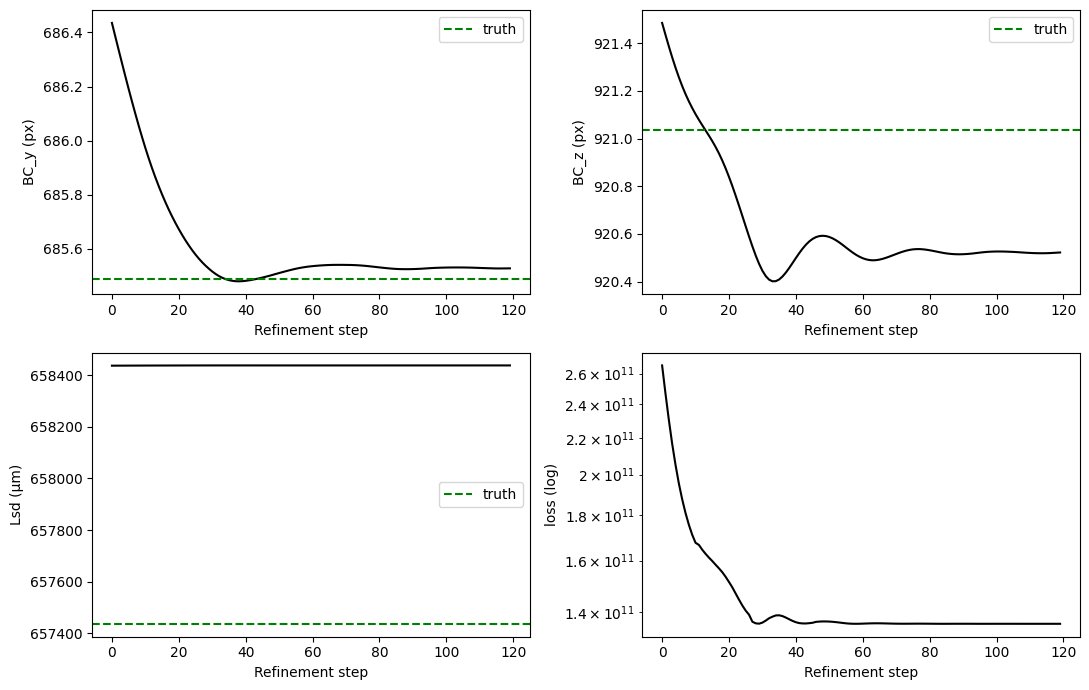

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, key, true_val, label in [
    (axes[0,0], "BC_y", true_BC_y, "BC_y (px)"),
    (axes[0,1], "BC_z", true_BC_z, "BC_z (px)"),
    (axes[1,0], "Lsd",  true_Lsd,  "Lsd (µm)"),
]:
    ax.plot(hist2[key], "k-")
    ax.axhline(true_val, color="green", ls="--", label="truth")
    ax.set_xlabel("Refinement step"); ax.set_ylabel(label)
    ax.legend()
ax = axes[1,1]
ax.plot(hist2["loss"], "k-")
ax.set_yscale("log")
ax.set_xlabel("Refinement step"); ax.set_ylabel("loss (log)")
plt.tight_layout()
plt.show()


**All three parameters converge** to (or near) their true values
together. The loss drops by 2-3 orders of magnitude.

**Why does this work?** Each parameter has a different "fingerprint"
on the ring shape (notebook 02 teaches you which one). The loss
gradient untangles them.

**The catch**: Lsd and wavelength are *degenerate* if you only have
one ring at one distance — they shift R the same way. Either fix
wavelength (you usually trust the beamline mono more than the detector
position) OR run multi-distance calibration (notebook 04).

## Common pitfalls

1. **Loss not decreasing** — usually the learning rate is too small,
   or you forgot `requires_grad=True`. Check `spec.BC_y.requires_grad`
   is True before constructing the optimizer.
2. **Loss going to NaN** — if your initial guess is so bad that no
   peak intensity lands in your loss-band R bins, the loss has zero
   gradient. Widen the band or reset the guess.
3. **Convergence stalls before truth** — you may have multiple
   parameters fighting each other (Lsd vs wavelength). Add ring
   information from a 2nd distance, or freeze one parameter.

## Try it yourself

1. Add `spec.ty` and `spec.tz` to the optimizer. Initialise them at
   0.0 (a flat detector). Does the refinement still find the calibrated
   tilts (~0.20° and ~0.45°)?
2. Use the second CeO₂ ring band (R ~243 px) instead of the first.
   Does the refinement converge faster, slower, or about the same?
3. Add a `GaussianPriorLoss` regulariser around the seed wavelength
   so the optimizer can't drift λ to compensate for Lsd.

## Next: 04 — Multi-Distance Calibration

The Lsd-vs-wavelength degeneracy goes away when you have rings at
multiple sample-to-detector distances. We'll synthesise three frames
at different Lsds and refine a *shared* BC_y across all of them.
